<a href="https://colab.research.google.com/github/japhari/japhari/blob/main/mnist_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

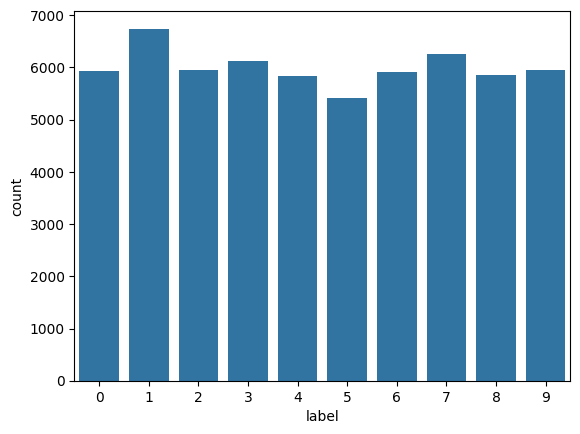

In [10]:
import tensorflow as tf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the MNIST dataset
#
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Convert y_train to a Pandas DataFrame
y_train_df = pd.DataFrame(y_train, columns=['label'])

# Plot the distribution of the labels using Seaborn
sns.countplot(data=y_train_df, x='label')

# Show the plot
plt.show()


In [11]:
np.isnan(x_train).any()

False

In [12]:
np.isnan(x_test).any()

False

### Setting the Input Shape

In [13]:
input_shape = (28, 28, 1)
# Pixels: 28px height, 28px width, and 1 channel (grayscale)

**Summary**

 `input_shape` is defined for a grayscale image of size 28x28 pixels. The `1` indicates that there is only one color channel since the images are black and white.

### Reshaping and Normalizing Training Data

In [14]:

x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
# Reshape the training data to include a single channel dimension
# x_train.shape[0] is the number of images
# x_train.shape[1] and x_train.shape[2] are the height and width of each image

x_train = x_train / 255.0
# Normalize the pixel values to the range [0, 1] by dividing by 255

The training data `x_train` is reshaped to include a channel dimension. This is necessary because convolutional neural networks (CNNs) expect a 4D tensor as input: `(number of images, height, width, channels)`. The pixel values are then normalized from the range [0, 255] to [0, 1] to help with the training process.

### Reshaping and Normalizing Test Data

In [15]:
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
# Reshape the test data to include a single channel dimension

x_test = x_test / 255.0
# Normalize the pixel values to the range [0, 1]

The test data `x_test` is reshaped and normalized.

### One-Hot Encoding the Labels

In [16]:
y_train = tf.one_hot(y_train.astype(np.int32), depth=10)
# Convert the training labels to one-hot encoded vectors with a depth of 10
# Each label will be represented as a vector of length 10

y_test = tf.one_hot(y_test.astype(np.int32), depth=10)
# Convert the test labels to one-hot encoded vectors with a depth of 10

The labels `y_train` and `y_test` are one-hot encoded. This means each label (which represents a digit from 0 to 9) is converted into a vector of length 10. For example, the label `5` is converted to `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`.

### Visualizing an Example Image and Its Label

tf.Tensor([0. 0. 0. 0. 0. 1. 0. 0. 0. 0.], shape=(10,), dtype=float32)


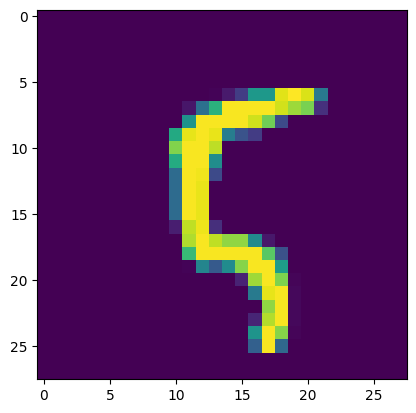

In [19]:

plt.imshow(x_train[100][:, :, 0])
#plt.imshow(x_train[100][:, :, 0], cmap='gray')
# Display the 100th image in the training set using matplotlib
# The cmap='gray' argument ensures the image is shown in grayscale

print(y_train[100])
# Print the one-hot encoded label for the 100th image
# Expected result: A one-hot encoded vector corresponding to the number five

In [20]:
batch_size = 64
num_classes = 10
epochs = 5

In [21]:

# Create a Sequential model
model = tf.keras.models.Sequential([
    # First convolutional layer
    tf.keras.layers.Conv2D(32, (5, 5), padding='same', activation='relu', input_shape=input_shape),
    # Adds 32 filters of size 5x5, with 'same' padding to preserve the input dimensions
    # ReLU activation function is used
    # The input shape of the images is specified here (height, width, channels)

    # Second convolutional layer
    tf.keras.layers.Conv2D(32, (5, 5), padding='same', activation='relu'),
    # Adds another 32 filters of size 5x5 with 'same' padding
    # ReLU activation function is used

    # Max pooling layer
    tf.keras.layers.MaxPool2D(),
    # Reduces the spatial dimensions (height and width) by taking the maximum value
    # from a 2x2 window, effectively downsampling the feature maps by a factor of 2

    # Dropout layer
    tf.keras.layers.Dropout(0.25),
    # Drops 25% of the neurons randomly to prevent overfitting

    # Third convolutional layer
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    # Adds 64 filters of size 3x3 with 'same' padding
    # ReLU activation function is used

    # Fourth convolutional layer
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    # Adds another 64 filters of size 3x3 with 'same' padding
    # ReLU activation function is used

    # Max pooling layer
    tf.keras.layers.MaxPool2D(strides=(2, 2)),
    # Reduces the spatial dimensions by taking the maximum value
    # from a 2x2 window with a stride of 2, downsampling the feature maps

    # Dropout layer
    tf.keras.layers.Dropout(0.25),
    # Drops 25% of the neurons randomly to prevent overfitting

    # Flatten layer
    tf.keras.layers.Flatten(),
    # Flattens the 3D feature maps into 1D feature vectors
    # This is necessary before feeding the data into fully connected layers

    # Fully connected (dense) layer
    tf.keras.layers.Dense(128, activation='relu'),
    # Adds a dense layer with 128 neurons
    # ReLU activation function is used

    # Dropout layer
    tf.keras.layers.Dropout(0.5),
    # Drops 50% of the neurons randomly to prevent overfitting

    # Output layer
    tf.keras.layers.Dense(num_classes, activation='softmax')
    # Adds the final dense layer with a number of neurons equal to the number of classes
    # Softmax activation function is used to get probability distributions over classes
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(epsilon=1e-08),
    # RMSprop optimizer is used with a small epsilon value for numerical stability

    loss='categorical_crossentropy',
    # Loss function is categorical crossentropy, suitable for multi-class classification

    metrics=['acc']
    # Accuracy is used as a metric to evaluate the model's performance
)

# Print the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        832       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        25632     
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 14, 14, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 64)        36928     
                                                        


### Summary

1. **Conv2D Layers**: These layers apply convolutional filters to the input image to extract features. The filters move over the image, performing convolution operations.
   - The first `Conv2D` layer specifies the `input_shape`.
   - Filters of different sizes (5x5, 3x3) are used.
   - ReLU activation is applied to introduce non-linearity.

2. **MaxPool2D Layers**: These layers downsample the spatial dimensions (height and width) by taking the maximum value within a defined window (usually 2x2).

3. **Dropout Layers**: These layers randomly set a fraction of the input units to 0 at each update during training time, which helps prevent overfitting.

4. **Flatten Layer**: Converts the 3D feature maps into 1D feature vectors, preparing them for the fully connected layers.

5. **Dense Layers**: These fully connected layers perform classification based on the extracted features. The first dense layer has 128 units with ReLU activation, and the final layer has units equal to the number of classes with softmax activation for multi-class classification.

6. **Model Compilation**: The model is compiled with the RMSprop optimizer, categorical crossentropy loss (for multi-class classification), and accuracy as the evaluation metric.



In [22]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('acc')>0.995):
      print("\nReached 99.5% accuracy so cancelling training!")
      self.model.stop_training = True

callbacks = myCallback()

In [23]:
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_split=0.1,
                    callbacks=[callbacks])

Epoch 1/5
844/844 [==============================] - 317s 374ms/step - loss: 0.2138 - acc: 0.9334 - val_loss: 0.0397 - val_acc: 0.9905
Epoch 2/5
844/844 [==============================] - 314s 373ms/step - loss: 0.0747 - acc: 0.9784 - val_loss: 0.0405 - val_acc: 0.9883
Epoch 3/5
844/844 [==============================] - 312s 369ms/step - loss: 0.0587 - acc: 0.9832 - val_loss: 0.0308 - val_acc: 0.9922
Epoch 4/5
844/844 [==============================] - 314s 372ms/step - loss: 0.0518 - acc: 0.9854 - val_loss: 0.0259 - val_acc: 0.9938
Epoch 5/5
844/844 [==============================] - 312s 370ms/step - loss: 0.0447 - acc: 0.9869 - val_loss: 0.0244 - val_acc: 0.9943


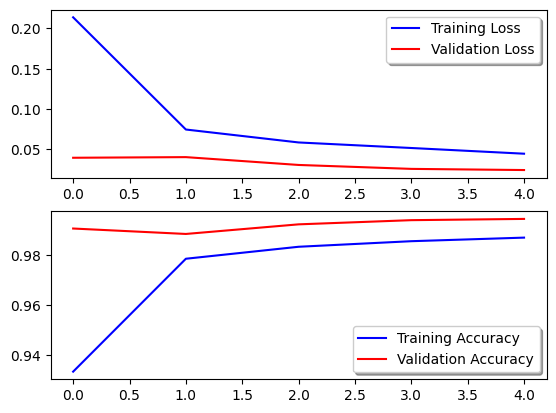

In [24]:
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training Loss")
ax[0].plot(history.history['val_loss'], color='r', label="Validation Loss",axes =ax[0])
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['acc'], color='b', label="Training Accuracy")
ax[1].plot(history.history['val_acc'], color='r',label="Validation Accuracy")
legend = ax[1].legend(loc='best', shadow=True)

In [25]:
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 [==============================] - 16s 52ms/step - loss: 0.0170 - acc: 0.9939


In [ ]:
# Predict the values from the testing dataset
Y_pred = model.predict(x_test)
# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred,axis = 1)
# Convert testing observations to one hot vectors
Y_true = np.argmax(y_test,axis = 1)
# compute the confusion matrix
confusion_mtx = tf.math.confusion_matrix(Y_true, Y_pred_classes)

313/313 [==============================] - 18s 57ms/step


<Axes: >

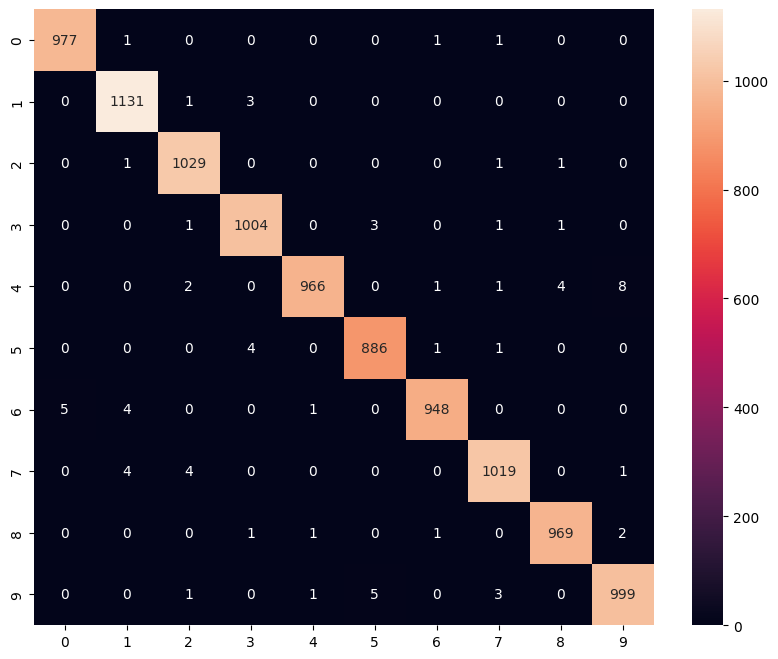

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='g')